# Forth practical work in Deep Learning course - part 2
**Name:** Maha Kahla 


**Purpose of the laboratory work:** to study the principles of generative adversarial networks (GAN) on the example of the task of image generation from CIFAR-10 dataset. To compare the performance of two architectures: ordinary GAN and DCGAN (Deep Convolutional GAN).

In this part we use the exactly same code as in the first part. we only change the architecture of both generator and discriminator to create DCGAN.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

In [2]:
# Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scale images to range [-1, 1]
])

train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

100%|██████████| 170M/170M [00:10<00:00, 16.0MB/s]


In [3]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [4]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

The following code defines a Generator model for a deep convolutional GAN (DCGAN) using PyTorch. the generator takes a latent vector and transforms it into a spatial feature map of size (512, 2, 2). In the network fully connected layer expands the latent vector into a 2 × 2 × 512 feature map, batch normalization normalizes activations to stabilize training , LeakyReLU activation helps prevent dying neurons.
Transpose convolutions gradually upsamples the feature map from 2×2 to 32×32 (CIFAR-10 image size) and the number of channels decreases progressively (512 → 256 → 128 → 64 → 3). and finally output layer (Tanh) converts the final image into the range [-1, 1] (for normalized image representation).

In [5]:
# Define the Generator
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 2 * 2 * 512),
            nn.BatchNorm1d(2 * 2 * 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Unflatten(1, (512, 2, 2)),

            nn.ConvTranspose2d(512, 256, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(256, 128, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(64, 3, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

The discriminator network takes in input an RGB image (3 × 32 × 32). Convolutional layers extract features from the input image while reducing spatial dimensions. each layer uses a kernel size of 5 and stride of 2 to downsample, Padding = 2 ensures image dimensions shrink properly. the network also use LeakyReLU activation which helps with gradient flow, preventing dead neurons. the dropout regularization: reduces overfitting by randomly disabling neurons. After the last convolution, the feature map is flattened into a 1D vector. Fully connected layer outputs a single value (0 or 1). Finally, sigmoid function produces a probability value between 0 and 1 to indicate fake or real image.

In [6]:
# Define the Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(256, 512, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Flatten(),
            nn.Linear(512 * 2 * 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
# Initialize models
latent_dim = 100

generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0003, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0003, betas=(0.5, 0.999))

Epoch [0/120], Batch [0/1563], D Loss: 0.6943, G Loss: 0.7616
Epoch [0/120], Batch [100/1563], D Loss: 0.5784, G Loss: 1.2735
Epoch [0/120], Batch [200/1563], D Loss: 0.3763, G Loss: 2.3812
Epoch [0/120], Batch [300/1563], D Loss: 0.5192, G Loss: 1.5894
Epoch [0/120], Batch [400/1563], D Loss: 0.4381, G Loss: 1.9946
Epoch [0/120], Batch [500/1563], D Loss: 0.4154, G Loss: 3.1033
Epoch [0/120], Batch [600/1563], D Loss: 0.4489, G Loss: 3.0743
Epoch [0/120], Batch [700/1563], D Loss: 0.4506, G Loss: 1.8107
Epoch [0/120], Batch [800/1563], D Loss: 0.5114, G Loss: 3.5125
Epoch [0/120], Batch [900/1563], D Loss: 0.6459, G Loss: 4.9441
Epoch [0/120], Batch [1000/1563], D Loss: 0.4280, G Loss: 2.8884
Epoch [0/120], Batch [1100/1563], D Loss: 0.2926, G Loss: 2.8698
Epoch [0/120], Batch [1200/1563], D Loss: 0.3586, G Loss: 2.4152
Epoch [0/120], Batch [1300/1563], D Loss: 0.3946, G Loss: 2.9560
Epoch [0/120], Batch [1400/1563], D Loss: 0.2972, G Loss: 3.7096
Epoch [0/120], Batch [1500/1563], D L

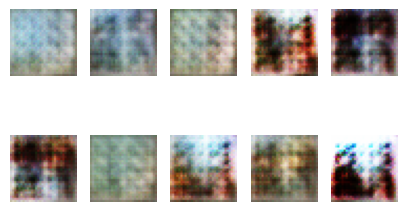

Epoch [1/120], Batch [0/1563], D Loss: 0.4177, G Loss: 2.9457
Epoch [1/120], Batch [100/1563], D Loss: 0.4554, G Loss: 3.5174
Epoch [1/120], Batch [200/1563], D Loss: 0.4087, G Loss: 3.1637
Epoch [1/120], Batch [300/1563], D Loss: 0.4050, G Loss: 2.9028
Epoch [1/120], Batch [400/1563], D Loss: 0.3924, G Loss: 2.9079
Epoch [1/120], Batch [500/1563], D Loss: 0.3975, G Loss: 3.2227
Epoch [1/120], Batch [600/1563], D Loss: 0.3806, G Loss: 3.3930
Epoch [1/120], Batch [700/1563], D Loss: 0.3731, G Loss: 1.9582
Epoch [1/120], Batch [800/1563], D Loss: 0.4445, G Loss: 2.7941
Epoch [1/120], Batch [900/1563], D Loss: 0.4817, G Loss: 2.5242
Epoch [1/120], Batch [1000/1563], D Loss: 0.5347, G Loss: 2.8865
Epoch [1/120], Batch [1100/1563], D Loss: 0.3135, G Loss: 3.1426
Epoch [1/120], Batch [1200/1563], D Loss: 0.4207, G Loss: 3.7774
Epoch [1/120], Batch [1300/1563], D Loss: 0.3781, G Loss: 2.7943
Epoch [1/120], Batch [1400/1563], D Loss: 0.4557, G Loss: 2.6883
Epoch [1/120], Batch [1500/1563], D L

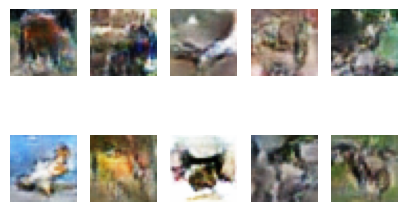

Epoch [11/120], Batch [0/1563], D Loss: 0.4715, G Loss: 1.6845
Epoch [11/120], Batch [100/1563], D Loss: 0.5424, G Loss: 1.3642
Epoch [11/120], Batch [200/1563], D Loss: 0.4687, G Loss: 2.1585
Epoch [11/120], Batch [300/1563], D Loss: 0.4412, G Loss: 2.2060
Epoch [11/120], Batch [400/1563], D Loss: 0.4236, G Loss: 1.9694
Epoch [11/120], Batch [500/1563], D Loss: 0.4784, G Loss: 2.0721
Epoch [11/120], Batch [600/1563], D Loss: 0.4368, G Loss: 1.7884
Epoch [11/120], Batch [700/1563], D Loss: 0.4443, G Loss: 1.9319
Epoch [11/120], Batch [800/1563], D Loss: 0.4529, G Loss: 2.0129
Epoch [11/120], Batch [900/1563], D Loss: 0.5446, G Loss: 1.7102
Epoch [11/120], Batch [1000/1563], D Loss: 0.4729, G Loss: 1.6493
Epoch [11/120], Batch [1100/1563], D Loss: 0.4181, G Loss: 2.1489
Epoch [11/120], Batch [1200/1563], D Loss: 0.4644, G Loss: 1.8856
Epoch [11/120], Batch [1300/1563], D Loss: 0.6108, G Loss: 1.9834
Epoch [11/120], Batch [1400/1563], D Loss: 0.4629, G Loss: 1.7647
Epoch [11/120], Batch 

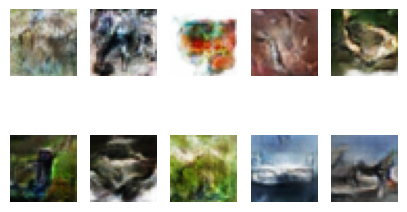

Epoch [21/120], Batch [0/1563], D Loss: 0.4730, G Loss: 2.3901
Epoch [21/120], Batch [100/1563], D Loss: 0.4152, G Loss: 1.6969
Epoch [21/120], Batch [200/1563], D Loss: 0.5157, G Loss: 1.5524
Epoch [21/120], Batch [300/1563], D Loss: 0.5610, G Loss: 2.2077
Epoch [21/120], Batch [400/1563], D Loss: 0.4582, G Loss: 2.1479
Epoch [21/120], Batch [500/1563], D Loss: 0.5714, G Loss: 1.4825
Epoch [21/120], Batch [600/1563], D Loss: 0.6286, G Loss: 1.3759
Epoch [21/120], Batch [700/1563], D Loss: 0.5824, G Loss: 1.5871
Epoch [21/120], Batch [800/1563], D Loss: 0.4645, G Loss: 2.0469
Epoch [21/120], Batch [900/1563], D Loss: 0.5175, G Loss: 1.6337
Epoch [21/120], Batch [1000/1563], D Loss: 0.4516, G Loss: 1.8693
Epoch [21/120], Batch [1100/1563], D Loss: 0.5092, G Loss: 1.6086
Epoch [21/120], Batch [1200/1563], D Loss: 0.4978, G Loss: 1.6312
Epoch [21/120], Batch [1300/1563], D Loss: 0.4789, G Loss: 1.7465
Epoch [21/120], Batch [1400/1563], D Loss: 0.5071, G Loss: 1.9507
Epoch [21/120], Batch 

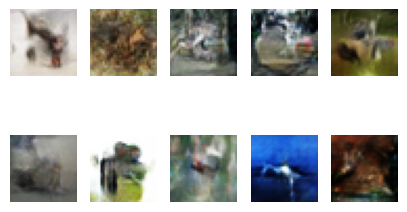

Epoch [31/120], Batch [0/1563], D Loss: 0.4692, G Loss: 1.3597
Epoch [31/120], Batch [100/1563], D Loss: 0.3848, G Loss: 1.8617
Epoch [31/120], Batch [200/1563], D Loss: 0.6484, G Loss: 1.9678
Epoch [31/120], Batch [300/1563], D Loss: 0.5356, G Loss: 2.1031
Epoch [31/120], Batch [400/1563], D Loss: 0.4705, G Loss: 1.6695
Epoch [31/120], Batch [500/1563], D Loss: 0.5329, G Loss: 1.6432
Epoch [31/120], Batch [600/1563], D Loss: 0.4503, G Loss: 1.8448
Epoch [31/120], Batch [700/1563], D Loss: 0.4585, G Loss: 1.8053
Epoch [31/120], Batch [800/1563], D Loss: 0.4679, G Loss: 1.8597
Epoch [31/120], Batch [900/1563], D Loss: 0.4377, G Loss: 1.7017
Epoch [31/120], Batch [1000/1563], D Loss: 0.4768, G Loss: 1.5004
Epoch [31/120], Batch [1100/1563], D Loss: 0.5651, G Loss: 1.7525
Epoch [31/120], Batch [1200/1563], D Loss: 0.4524, G Loss: 2.1526
Epoch [31/120], Batch [1300/1563], D Loss: 0.5685, G Loss: 1.3595
Epoch [31/120], Batch [1400/1563], D Loss: 0.4493, G Loss: 2.1265
Epoch [31/120], Batch 

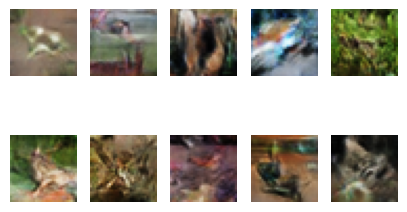

Epoch [41/120], Batch [0/1563], D Loss: 0.5302, G Loss: 1.6385
Epoch [41/120], Batch [100/1563], D Loss: 0.3627, G Loss: 2.1195
Epoch [41/120], Batch [200/1563], D Loss: 0.4658, G Loss: 1.9123
Epoch [41/120], Batch [300/1563], D Loss: 0.5473, G Loss: 1.7058
Epoch [41/120], Batch [400/1563], D Loss: 0.4592, G Loss: 1.6341
Epoch [41/120], Batch [500/1563], D Loss: 0.4207, G Loss: 1.9835
Epoch [41/120], Batch [600/1563], D Loss: 0.4069, G Loss: 2.6027
Epoch [41/120], Batch [700/1563], D Loss: 0.5558, G Loss: 2.3418
Epoch [41/120], Batch [800/1563], D Loss: 0.5396, G Loss: 1.9288
Epoch [41/120], Batch [900/1563], D Loss: 0.5967, G Loss: 1.6469
Epoch [41/120], Batch [1000/1563], D Loss: 0.4531, G Loss: 1.8965
Epoch [41/120], Batch [1100/1563], D Loss: 0.3518, G Loss: 2.2455
Epoch [41/120], Batch [1200/1563], D Loss: 0.5066, G Loss: 1.6505
Epoch [41/120], Batch [1300/1563], D Loss: 0.5562, G Loss: 2.2060
Epoch [41/120], Batch [1400/1563], D Loss: 0.4785, G Loss: 1.7343
Epoch [41/120], Batch 

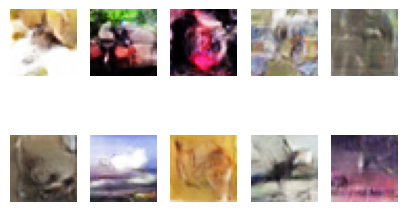

Epoch [51/120], Batch [0/1563], D Loss: 0.4604, G Loss: 1.9055
Epoch [51/120], Batch [100/1563], D Loss: 0.4697, G Loss: 1.7415
Epoch [51/120], Batch [200/1563], D Loss: 0.4497, G Loss: 2.2782
Epoch [51/120], Batch [300/1563], D Loss: 0.4659, G Loss: 2.1153
Epoch [51/120], Batch [400/1563], D Loss: 0.4980, G Loss: 1.6617
Epoch [51/120], Batch [500/1563], D Loss: 0.4224, G Loss: 2.2289
Epoch [51/120], Batch [600/1563], D Loss: 0.4596, G Loss: 1.6369
Epoch [51/120], Batch [700/1563], D Loss: 0.4425, G Loss: 1.8055
Epoch [51/120], Batch [800/1563], D Loss: 0.4931, G Loss: 1.7183
Epoch [51/120], Batch [900/1563], D Loss: 0.4104, G Loss: 1.9647
Epoch [51/120], Batch [1000/1563], D Loss: 0.5247, G Loss: 1.9568
Epoch [51/120], Batch [1100/1563], D Loss: 0.4730, G Loss: 1.5335
Epoch [51/120], Batch [1200/1563], D Loss: 0.4829, G Loss: 1.9186
Epoch [51/120], Batch [1300/1563], D Loss: 0.6444, G Loss: 1.8942
Epoch [51/120], Batch [1400/1563], D Loss: 0.5546, G Loss: 1.9374
Epoch [51/120], Batch 

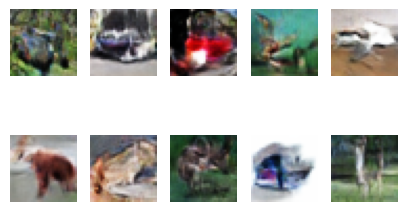

Epoch [61/120], Batch [0/1563], D Loss: 0.4827, G Loss: 1.9301
Epoch [61/120], Batch [100/1563], D Loss: 0.4734, G Loss: 1.8550
Epoch [61/120], Batch [200/1563], D Loss: 0.5185, G Loss: 1.6456
Epoch [61/120], Batch [300/1563], D Loss: 0.4328, G Loss: 1.5235
Epoch [61/120], Batch [400/1563], D Loss: 0.4812, G Loss: 1.7209
Epoch [61/120], Batch [500/1563], D Loss: 0.5011, G Loss: 1.6260
Epoch [61/120], Batch [600/1563], D Loss: 0.5132, G Loss: 1.9313
Epoch [61/120], Batch [700/1563], D Loss: 0.4819, G Loss: 1.8673
Epoch [61/120], Batch [800/1563], D Loss: 0.4182, G Loss: 1.4509
Epoch [61/120], Batch [900/1563], D Loss: 0.4894, G Loss: 1.8305
Epoch [61/120], Batch [1000/1563], D Loss: 0.5232, G Loss: 1.8565
Epoch [61/120], Batch [1100/1563], D Loss: 0.4846, G Loss: 1.9816
Epoch [61/120], Batch [1200/1563], D Loss: 0.4143, G Loss: 1.6748
Epoch [61/120], Batch [1300/1563], D Loss: 0.4489, G Loss: 2.6909
Epoch [61/120], Batch [1400/1563], D Loss: 0.4045, G Loss: 1.6419
Epoch [61/120], Batch 

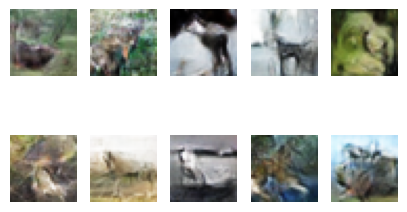

Epoch [71/120], Batch [0/1563], D Loss: 0.4571, G Loss: 1.7738
Epoch [71/120], Batch [100/1563], D Loss: 0.3791, G Loss: 2.4521
Epoch [71/120], Batch [200/1563], D Loss: 0.4910, G Loss: 1.6994
Epoch [71/120], Batch [300/1563], D Loss: 0.4085, G Loss: 2.2158
Epoch [71/120], Batch [400/1563], D Loss: 0.4940, G Loss: 1.4765
Epoch [71/120], Batch [500/1563], D Loss: 0.6391, G Loss: 1.7518
Epoch [71/120], Batch [600/1563], D Loss: 0.4543, G Loss: 2.0352
Epoch [71/120], Batch [700/1563], D Loss: 0.5419, G Loss: 1.9546
Epoch [71/120], Batch [800/1563], D Loss: 0.4423, G Loss: 2.1218
Epoch [71/120], Batch [900/1563], D Loss: 0.5151, G Loss: 2.8630
Epoch [71/120], Batch [1000/1563], D Loss: 0.4983, G Loss: 1.8363
Epoch [71/120], Batch [1100/1563], D Loss: 0.4828, G Loss: 1.8775
Epoch [71/120], Batch [1200/1563], D Loss: 0.4544, G Loss: 1.6161
Epoch [71/120], Batch [1300/1563], D Loss: 0.5035, G Loss: 1.4553
Epoch [71/120], Batch [1400/1563], D Loss: 0.4482, G Loss: 2.1099
Epoch [71/120], Batch 

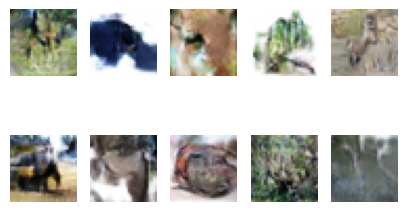

Epoch [81/120], Batch [0/1563], D Loss: 0.5203, G Loss: 1.9815
Epoch [81/120], Batch [100/1563], D Loss: 0.6774, G Loss: 1.7186
Epoch [81/120], Batch [200/1563], D Loss: 0.5206, G Loss: 2.0201
Epoch [81/120], Batch [300/1563], D Loss: 0.4608, G Loss: 2.0124
Epoch [81/120], Batch [400/1563], D Loss: 0.4652, G Loss: 2.7814
Epoch [81/120], Batch [500/1563], D Loss: 0.4341, G Loss: 1.4158
Epoch [81/120], Batch [600/1563], D Loss: 0.4461, G Loss: 1.8435
Epoch [81/120], Batch [700/1563], D Loss: 0.4495, G Loss: 1.3886
Epoch [81/120], Batch [800/1563], D Loss: 0.4927, G Loss: 1.7446
Epoch [81/120], Batch [900/1563], D Loss: 0.4129, G Loss: 1.8368
Epoch [81/120], Batch [1000/1563], D Loss: 0.5361, G Loss: 1.6399
Epoch [81/120], Batch [1100/1563], D Loss: 0.4676, G Loss: 2.2330
Epoch [81/120], Batch [1200/1563], D Loss: 0.4950, G Loss: 2.0003
Epoch [81/120], Batch [1300/1563], D Loss: 0.3937, G Loss: 2.3277
Epoch [81/120], Batch [1400/1563], D Loss: 0.4828, G Loss: 1.7538
Epoch [81/120], Batch 

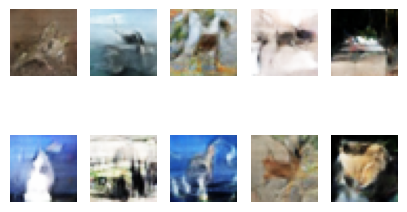

Epoch [91/120], Batch [0/1563], D Loss: 0.4635, G Loss: 1.7999
Epoch [91/120], Batch [100/1563], D Loss: 0.4999, G Loss: 1.6573
Epoch [91/120], Batch [200/1563], D Loss: 0.4698, G Loss: 1.8146
Epoch [91/120], Batch [300/1563], D Loss: 0.4229, G Loss: 1.8192
Epoch [91/120], Batch [400/1563], D Loss: 0.4847, G Loss: 2.4603
Epoch [91/120], Batch [500/1563], D Loss: 0.4663, G Loss: 1.9646
Epoch [91/120], Batch [600/1563], D Loss: 0.4823, G Loss: 2.0786
Epoch [91/120], Batch [700/1563], D Loss: 0.3797, G Loss: 1.9921
Epoch [91/120], Batch [800/1563], D Loss: 0.3922, G Loss: 1.8072
Epoch [91/120], Batch [900/1563], D Loss: 0.5218, G Loss: 2.3631
Epoch [91/120], Batch [1000/1563], D Loss: 0.4054, G Loss: 1.9823
Epoch [91/120], Batch [1100/1563], D Loss: 0.5495, G Loss: 1.7408
Epoch [91/120], Batch [1200/1563], D Loss: 0.3944, G Loss: 2.2076
Epoch [91/120], Batch [1300/1563], D Loss: 0.5097, G Loss: 1.9775
Epoch [91/120], Batch [1400/1563], D Loss: 0.4774, G Loss: 2.1802
Epoch [91/120], Batch 

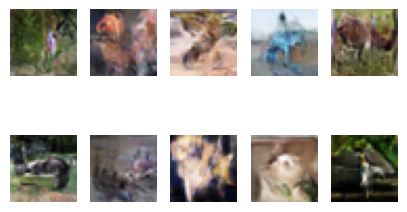

Epoch [101/120], Batch [0/1563], D Loss: 0.4105, G Loss: 1.9695
Epoch [101/120], Batch [100/1563], D Loss: 0.5049, G Loss: 1.4788
Epoch [101/120], Batch [200/1563], D Loss: 0.5094, G Loss: 2.0016
Epoch [101/120], Batch [300/1563], D Loss: 0.5140, G Loss: 1.8995
Epoch [101/120], Batch [400/1563], D Loss: 0.5500, G Loss: 1.2921
Epoch [101/120], Batch [500/1563], D Loss: 0.4629, G Loss: 1.7852
Epoch [101/120], Batch [600/1563], D Loss: 0.4936, G Loss: 2.4780
Epoch [101/120], Batch [700/1563], D Loss: 0.4736, G Loss: 2.3045
Epoch [101/120], Batch [800/1563], D Loss: 0.3608, G Loss: 1.9747
Epoch [101/120], Batch [900/1563], D Loss: 0.4983, G Loss: 1.8660
Epoch [101/120], Batch [1000/1563], D Loss: 0.5135, G Loss: 2.2199
Epoch [101/120], Batch [1100/1563], D Loss: 0.4311, G Loss: 2.0583
Epoch [101/120], Batch [1200/1563], D Loss: 0.5168, G Loss: 1.7239
Epoch [101/120], Batch [1300/1563], D Loss: 0.3888, G Loss: 1.7782
Epoch [101/120], Batch [1400/1563], D Loss: 0.4847, G Loss: 1.7880
Epoch [

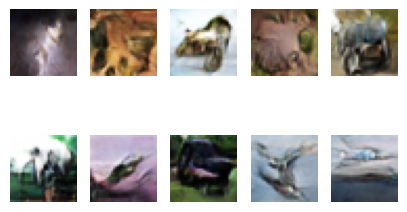

Epoch [111/120], Batch [0/1563], D Loss: 0.3791, G Loss: 2.1342
Epoch [111/120], Batch [100/1563], D Loss: 0.4808, G Loss: 1.6339
Epoch [111/120], Batch [200/1563], D Loss: 0.4798, G Loss: 2.2066
Epoch [111/120], Batch [300/1563], D Loss: 0.4632, G Loss: 1.7235
Epoch [111/120], Batch [400/1563], D Loss: 0.5880, G Loss: 1.7122
Epoch [111/120], Batch [500/1563], D Loss: 0.5782, G Loss: 1.3800
Epoch [111/120], Batch [600/1563], D Loss: 0.4075, G Loss: 2.6077
Epoch [111/120], Batch [700/1563], D Loss: 0.5440, G Loss: 1.7941
Epoch [111/120], Batch [800/1563], D Loss: 0.4896, G Loss: 1.7699
Epoch [111/120], Batch [900/1563], D Loss: 0.4757, G Loss: 2.0566
Epoch [111/120], Batch [1000/1563], D Loss: 0.4812, G Loss: 2.4600
Epoch [111/120], Batch [1100/1563], D Loss: 0.5056, G Loss: 1.5743
Epoch [111/120], Batch [1200/1563], D Loss: 0.5707, G Loss: 2.1138
Epoch [111/120], Batch [1300/1563], D Loss: 0.4542, G Loss: 1.7155
Epoch [111/120], Batch [1400/1563], D Loss: 0.4406, G Loss: 1.7463
Epoch [

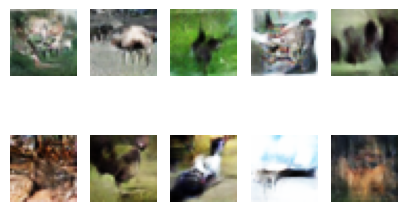

In [9]:
# Training loop
epochs = 120
batch_size = 32
smooth = 0.1

d_loss_history = []
g_loss_history = []

for epoch in range(epochs + 1):
    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.full((batch_size, 1), 1 - smooth, device=device)
        fake_labels = torch.zeros((batch_size, 1), device=device)

        # Train Discriminator
        optimizer_D.zero_grad()
        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(z)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()
        optimizer_G.step()

        if i % 100 == 0:
            print(f"Epoch [{epoch}/{epochs}], Batch [{i}/{len(train_loader)}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

    d_loss_history.append(d_loss.item())
    g_loss_history.append(g_loss.item())

    if epoch % 10 == 0:
        generator.eval()
        with torch.no_grad():
            z = torch.randn(10, latent_dim, device=device)
            fake_images = generator(z).cpu().permute(0, 2, 3, 1).numpy()
            fake_images = (fake_images + 1) / 2  # Rescale to [0,1]

        fig, axes = plt.subplots(2, 5, figsize=(5, 3))
        for ax, img in zip(axes.flatten(), fake_images):
            ax.imshow(img)
            ax.axis('off')
        plt.show()
        generator.train()

The training loop code is similar to the one in the first part, we plot the losses:

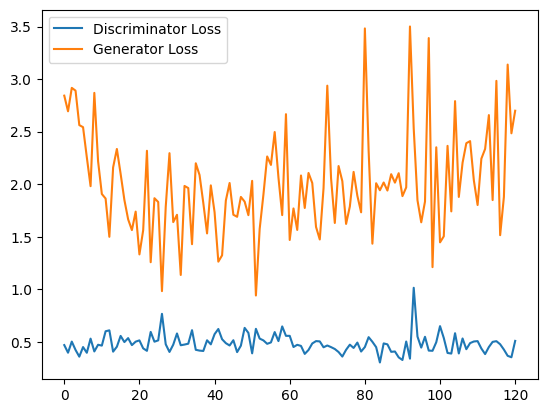

In [10]:
# Plot loss
plt.plot(d_loss_history, label="Discriminator Loss")
plt.plot(g_loss_history, label="Generator Loss")
plt.legend()
plt.show()

From the graphs we can notice that the discriminator loss is fairly stable and low (~0.5), which indicates that the discriminator is effectively distinguishing real and fake images. however, there are some minor fluctuations, but overall, it looks well-trained.
On the other hand, the generator loss is highly unstable and increasing over time, this suggests that the generator is struggling to fool the discriminator.As a result, the increasing trend implies the denerator is not improving, and the discriminator is overpowering it.

Possible improvements: reducing the discriminator's learning rate to prevent it from dominating too quickly, trying adding more noise to the discriminator’s input to make it less confident and increasing batch size to stabilize gradients.

In [11]:
# Save the generator model
torch.save(generator.state_dict(), 'generator.pth')

# Save the discriminator model
torch.save(discriminator.state_dict(), 'discriminator.pth')

In [19]:
# Load the generator model
generator = Generator(latent_dim)  # Replace with your generator class
generator.load_state_dict(torch.load('generator.pth'))
generator.eval()  # Set to evaluation mode if you're generating images

# Load the discriminator model
discriminator = Discriminator()  # Replace with your discriminator class
discriminator.load_state_dict(torch.load('discriminator.pth'))
discriminator.eval()  # Set to evaluation mode if needed

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): Conv2d(256, 512, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=2048, out_features=1, bias=True)
    (14): Sigmoid()
  )
)

In [20]:
generator

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Unflatten(dim=1, unflattened_size=(512, 2, 2))
    (4): ConvTranspose2d(512, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [26]:
latent_dim

100

In [31]:
generator.to(device)

# Generate random noise
noise = torch.randn( 64,100, device=device)  # Adjust dimensions as needed

# Generate images
with torch.no_grad():
    generated_images = generator(noise)

In [32]:
generated_images = generated_images.detach().cpu().numpy()
generated_images = (generated_images + 1) / 2

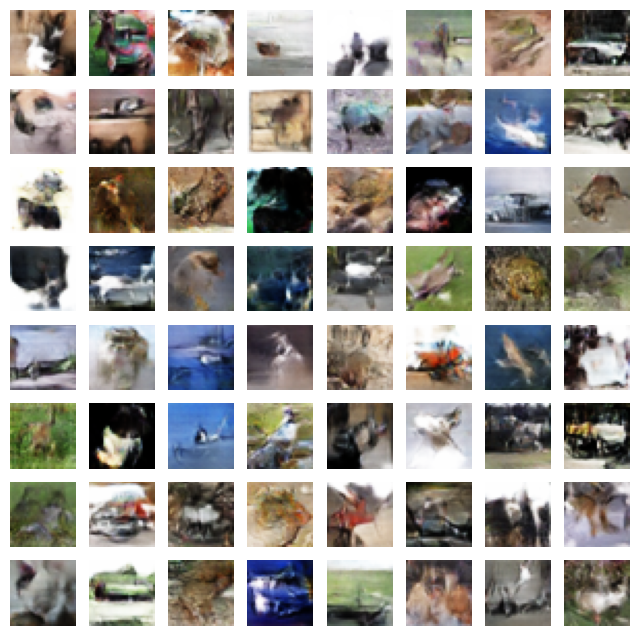

In [33]:
# Plotting the images
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(8, 8))
for i in range(64):
    ax = axes[i // 8, i % 8]
    ax.imshow(generated_images[i].transpose(1, 2, 0))  # Change shape from (C, H, W) to (H, W, C)
    ax.axis('off')
plt.show()

At the end we display some of the generated images, we can see that the quality of the results is much better than the generated images using GAN model.

Results: GAN vs DCGAN:
DCGANs use convolutional and transposed convolutional layers, preserving the spatial relationships and generating more realistic images.
A fully connected network in GAN might struggle to learn textures or object boundaries.
DCGANs tend to train more stably and generate better-looking images faster than GANs. This is becuase of using batch normalization and using of ReLU which improves gradient flow.
Using CNN we get higher resolution.
ConvTranspose2D layers in DCGAN help the Generator gradually upsample noise into a structured image.
